# Classification DPE — Performant / Passable / Energivore
## Pipeline Regression Logistique (4 variantes)

**Entree :** `data_for_processing_v2.xlsx` — la colonne `etiquette_dpe` contient directement les 3 groupes cibles.

**Objectif :** entrainer et comparer 4 variantes de regression logistique sur les memes donnees
(meme split, meme preprocesseur), afin d'avoir une base de reference simple et interpretable
avant de voir le meilleur que l'on prendra 

**Variantes entrainees :**
1. Regression Logistique **Elastic Net** (penalite L1 + L2 combinee)
2. Regression Logistique **Ridge** (penalite L2)
3. Regression Logistique **Lasso** (penalite L1, selection de variables)

Pour chaque variante : optimisation des hyperparametres avec Optuna (incluant les poids de
classe, car le jeu de donnees est fortement desequilibre), puis entrainement final, puis
evaluation complete.

**Pas de calibration** des probabilites dans ce notebook (volontairement laissee de cote).

**Plan du notebook :**
1. Imports et configuration
2. Chargement des donnees
3. Pretraitement
4. Split train / test
5. Pipeline et preprocesseur partage
6. Entrainement des modeles candidats (Optuna)
   - 6.1 Regression Logistique Elastic Net
   - 6.2 Regression Logistique Ridge
   - 6.3 Regression Logistique Lasso
7. Comparaison des 3 variantes
8. Evaluation detaillee du meilleur modele
   - 8.1 Courbes d'apprentissage (train vs validation)
   - 8.2 Matrice de confusion
   - 8.3 Rapport de classification (precision / rappel / F1 par classe)
   - 8.4 Courbes ROC et Precision-Rappel (one-vs-rest)
   - 8.5 Interpretation des coefficients (odds-ratio)
9. Conclusion


## 1. Imports et configuration

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.preprocessing import RobustScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, learning_curve
)
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve
)
from category_encoders import TargetEncoder

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
%matplotlib inline


####################################### A PARAMETRER ################################

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Les 3 groupes metier, directement disponibles dans la colonne cible
TARGET = "etiquette_dpe"
GROUPS = ["Performant", "Passable", "Energivore"]

GROUP_COLORS = {
    "Performant": "#00923F",
    "Passable":   "#F2C12B",
    "Energivore": "#E6442E",
}

N_TRIALS = 25  # nombre d'essais Optuna par variante de modele

print("Imports OK")
print(f"  Cible : '{TARGET}' -> {GROUPS}")


Imports OK
  Cible : 'etiquette_dpe' -> ['Performant', 'Passable', 'Energivore']


## 2. Chargement des donnees

In [82]:
FILE_PATH = "resources/data_for_processing_final.xlsx"

df = pd.read_excel(FILE_PATH)
print(f"Dataset : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"Valeurs manquantes : {df.isnull().sum().sum()}")

vals = df[TARGET].unique()
print(f"\nValeurs uniques de '{TARGET}' : {sorted(vals)}")
print("Cible validee, les 3 groupes attendus sont presents")

print("\nDistribution de la cible :")
vc = df[TARGET].value_counts().reindex(GROUPS)
for grp, cnt in vc.items():
    pct = cnt / len(df) * 100
    bar = "#" * int(pct / 2)
    print(f"  {grp:<12} {cnt:6,}  ({pct:5.1f}%)  {bar}")

print(f"\nRatio de desequilibre : {vc.max() / vc.min():.1f}:1")


Dataset : 55,357 lignes x 25 colonnes
Valeurs manquantes : 9

Valeurs uniques de 'etiquette_dpe' : ['Energivore', 'Passable', 'Performant']
Cible validee, les 3 groupes attendus sont presents

Distribution de la cible :
  Performant    2,303  (  4.2%)  ##
  Passable     39,557  ( 71.5%)  ###################################
  Energivore   13,497  ( 24.4%)  ############

Ratio de desequilibre : 17.2:1


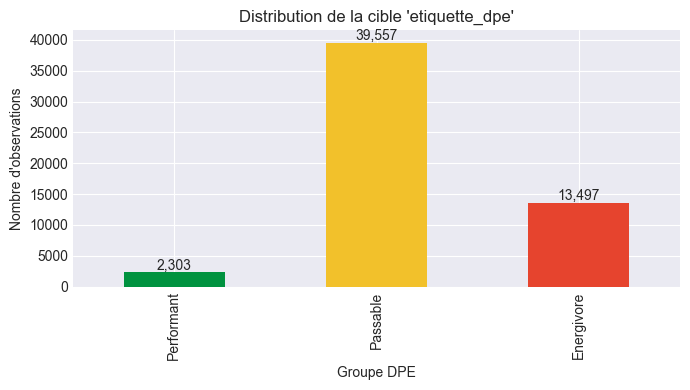

In [59]:
'''
Visualisation de la distribution de la cible.
Sert a illustrer le desequilibre des classes constate ci-dessus : utile pour justifier
plus loin l'usage de poids de classe dans la regression logistique plutot que la
seule exactitude (accuracy) comme critere d'evaluation (cf. cours, sensibilite de
l'accuracy aux jeux de donnees desequilibres).
'''
fig, ax = plt.subplots(figsize=(7, 4))
vc.plot(kind="bar", color=[GROUP_COLORS[g] for g in vc.index], ax=ax)
ax.set_title("Distribution de la cible 'etiquette_dpe'")
ax.set_xlabel("Groupe DPE")
ax.set_ylabel("Nombre d'observations")
for i, v in enumerate(vc.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


## 3. Pretraitement des donnees

In [60]:
def suppress_quasi_const(df):
    '''
    Supprime les colonnes quasi-constantes, c'est a dire les colonnes pour lesquelles
    une seule valeur represente plus de 95% des observations.

    Justification : une telle colonne n'apporte presque pas de variabilite au modele
    et se comporte essentiellement comme du bruit plutot que comme un signal utile.
    '''
    quasi_cst = [
        c for c in df.columns
        if c != TARGET
        and df[c].value_counts(normalize=True).iloc[0] > 0.95
    ]

    if quasi_cst:
        print(f"{'=' * 80}")
        print(f"Colonnes quasi-constantes supprimees ({len(quasi_cst)}) :")
        print(f"{'=' * 80}")
        for c in quasi_cst:
            top_val = df[c].value_counts(normalize=True).iloc[0]
            top_lab = df[c].value_counts().index[0]
            print(f"  {c:<50}  '{top_lab}' ({top_val:.1%})")
        df = df.drop(columns=quasi_cst)
    else:
        print(f"{'=' * 80}")
        print("Aucune colonne quasi-constante")
        print(f"{'=' * 80}")
    return df


def capping_outlier(df):
    '''
    Traitement des valeurs extremes :
    - hauteur_sous_plafond : ecretee (clip) a 6 metres, valeur jugee physiquement
      raisonnable pour un logement, au dela on considere une erreur de saisie.
    - colonnes a forte proportion de zeros (stockage ECS, production PV) : transformation
      log1p pour reduire l'asymetrie de la distribution sans perdre l'information des zeros.
    '''
    if "hauteur_sous_plafond" in df.columns:
        n = (df["hauteur_sous_plafond"] > 6.0).sum()
        df["hauteur_sous_plafond"] = df["hauteur_sous_plafond"].clip(upper=6.0)
        print(f"hauteur_sous_plafond clippee a 6m ({n} valeurs corrigees)")

    for col in ["volume_stockage_generateur_n1_ecs_n1",
                "production_electricite_pv_kwhep_par_an"]:
        if col in df.columns:
            df[col] = np.log1p(df[col])
            print(f"{col} -> log1p")

    print(f"\n{'=' * 80}")
    print(f"Dataset apres nettoyage : {df.shape[0]:,} x {df.shape[1]}")
    print(f"{'=' * 80}")
    return df

def encoding_ordinal(df):
    ordinal_vars = {
        'qualite_isolation_enveloppe':   ['insuffisante', 'moyenne', 'bonne', 'très bonne'],
        'qualite_isolation_murs':        ['insuffisante', 'moyenne', 'bonne', 'très bonne'],
        'qualite_isolation_menuiseries':  ['insuffisante', 'moyenne', 'bonne', 'très bonne'],
        'qualite_isolation_plancher_bas': ['insuffisante', 'moyenne', 'bonne', 'très bonne'],
        'classe_inertie_batiment':        ['Légère', 'Moyenne', 'Lourde', 'Très lourde'],
        'periode_construction':           ['ancien', 'transition', 'moderne', 'recent', 'tres_recent'],
    }

    for col, order in ordinal_vars.items():
        if col not in df.columns:
            continue
        vals_in_data = set(df[col].dropna().unique())
        vals_in_order = set(order)
        unexpected = vals_in_data - vals_in_order
        if unexpected:
            print(f"⚠️  {col}: valeurs non prévues dans l'ordre → {unexpected}")
            for uv in unexpected:
                order.append(uv)

        mapping = {v: i for i, v in enumerate(order)}
        df[col + '_enc'] = df[col].map(mapping)
        n_nan = df[col + '_enc'].isnull().sum()
        print(f"{col} → encodé ({len(order)} niveaux, {n_nan} NaN)")

    # Suppression des colonnes d'origine, une fois encodées
    df = df.drop(columns=list(ordinal_vars.keys()))
    return df   # <-- la ligne qui manquait




In [61]:
def classe_features(df):
    '''
    Classe les colonnes du dataframe en 4 groupes selon le traitement qu'elles
    recevront dans le preprocesseur :
    - ordinal_enc_cols  : deja encodees en amont (suffixe '_enc'), passees telles quelles.
    - binary_cols       : variables binaires, passees telles quelles.
    - quant_cols        : variables numeriques continues, a mettre a l'echelle.
    - qual_cols         : variables qualitatives nominales restantes, a encoder (TargetEncoder).
    '''
    ordinal_enc_cols = [c for c in df.columns if c.endswith("_enc")]

    binary_cols = [c for c in ["ventilation_posterieure_2012"] if c in df.columns]

    base_num = ["hauteur_sous_plafond", "volume_stockage_generateur_n1_ecs_n1",
                "production_electricite_pv_kwhep_par_an"]
    quant_cols = [c for c in base_num if c in df.columns]

    exclude = [TARGET] + ordinal_enc_cols + binary_cols + quant_cols
    qual_cols = [
        c for c in df.columns
        if c not in exclude
        and (df[c].dtype == object or str(df[c].dtype) == "str")
    ]

    passthrough_cols = ordinal_enc_cols + binary_cols
    all_features = quant_cols + qual_cols + passthrough_cols

    print(f"\n{'=' * 40} Features pour le modele {'=' * 40}")
    print(f"Features totales : {len(all_features)}")
    print(f"  Numeriques   ({len(quant_cols)}) : {quant_cols}")
    print(f"  Qualitatives ({len(qual_cols)})")
    print(f"  Passthrough  ({len(passthrough_cols)})")
    print(f"{'=' * 80}")

    return all_features, quant_cols, qual_cols, passthrough_cols


def preprocessing(df):
    '''Enchaine les 3 etapes de nettoyage / classement des colonnes.'''
    df_suppr_quasi_const = suppress_quasi_const(df)
    df_process = capping_outlier(df_suppr_quasi_const)
    df_process_ordinal = encoding_ordinal(df_process)
    all_features, quant_cols, qual_cols, passthrough_cols = classe_features(df_process_ordinal)
    return df_process_ordinal, all_features, quant_cols, qual_cols, passthrough_cols


In [62]:
df_data, all_features, quant_cols, qual_cols, passthrough_cols = preprocessing(df)


Colonnes quasi-constantes supprimees (6) :
  zone_climatique                                     'H1a' (99.9%)
  classe_altitude                                     'inférieur à 400m' (100.0%)
  configuration_installation_chauffage_n1             'standard' (99.7%)
  configuration_installation_ecs_n1                   'Un seul système d'ECS sans solaire' (98.7%)
  type_installation_solaire_n1                        'Non affecté' (99.3%)
  production_electricite_pv_kwhep_par_an              '0.0' (98.9%)
hauteur_sous_plafond clippee a 6m (20 valeurs corrigees)
volume_stockage_generateur_n1_ecs_n1 -> log1p

Dataset apres nettoyage : 55,357 x 19
qualite_isolation_enveloppe → encodé (4 niveaux, 0 NaN)
qualite_isolation_murs → encodé (4 niveaux, 0 NaN)
qualite_isolation_menuiseries → encodé (4 niveaux, 0 NaN)
qualite_isolation_plancher_bas → encodé (4 niveaux, 0 NaN)
classe_inertie_batiment → encodé (4 niveaux, 0 NaN)
periode_construction → encodé (5 niveaux, 0 NaN)

=======================

## 4. Split train / test

In [63]:
'''
Separation stratifiee train/test (80/20). La stratification garantit que la
proportion des 3 groupes DPE reste identique entre train et test, ce qui est
indispensable ici puisque les classes sont fortement desequilibrees (cf. section 2).
'''
X = df_data[all_features].copy()
y = df_data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")
print()
print("Distribution train :")
for grp in GROUPS:
    cnt = (y_train == grp).sum()
    pct = cnt / len(y_train) * 100
    print(f"  {grp:<12} {cnt:6,}  ({pct:.1f}%)")

print("\nVerification de la stratification :")
for grp in GROUPS:
    p_tr = (y_train == grp).mean() * 100
    p_te = (y_test == grp).mean() * 100
    delta = abs(p_tr - p_te)
    flag = "OK" if delta < 1.0 else "ATTENTION"
    print(f"  {grp:<12} train={p_tr:.1f}%  test={p_te:.1f}%  delta={delta:.2f}%  {flag}")


Train : 44,285  |  Test : 11,072

Distribution train :
  Performant    1,842  (4.2%)
  Passable     31,645  (71.5%)
  Energivore   10,798  (24.4%)

Verification de la stratification :
  Performant   train=4.2%  test=4.2%  delta=0.00%  OK
  Passable     train=71.5%  test=71.5%  delta=0.00%  OK
  Energivore   train=24.4%  test=24.4%  delta=0.01%  OK


## 5. Pipeline et preprocesseur partage

Le meme `make_preprocessor()` est utilise pour les 3 variantes de regression
logistique : meme encodage des variables qualitatives, meme mise a l'echelle des
variables numeriques. Cela garantit une comparaison strictement equitable entre
les 3 modeles.

In [64]:
def make_preprocessor():
    '''
    Construit le ColumnTransformer partage par toutes les variantes de regression
    logistique :
    - num  : RobustScaler sur les variables numeriques continues. Ce scaler est
      peu sensible aux valeurs aberrantes (utilise la mediane et l'IQR plutot que
      la moyenne et l'ecart-type), ce qui est important car la regression
      logistique est sensible a l'echelle des variables.
    - cat  : TargetEncoder sur les variables qualitatives nominales. Remplace
      chaque modalite par une statistique liee a la cible plutot que de creer
      une colonne par modalite (eviter l'explosion dimensionnelle du One-Hot).
    - pass : variables deja encodees ou binaires, passees sans transformation.
    '''
    cat_tr = TargetEncoder(smoothing=3.0, min_samples_leaf=50)

    transformers = [("num", RobustScaler(), quant_cols)]
    if qual_cols:
        transformers.append(("cat", cat_tr, qual_cols))
    if passthrough_cols:
        transformers.append(("pass", "passthrough", passthrough_cols))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )


def make_model_pipeline(estimator):
    '''Encapsule un estimateur quelconque dans le pipeline de preprocessing partage.'''
    return Pipeline([
        ("pre", make_preprocessor()),
        ("clf", estimator),
    ])


print("make_preprocessor() et make_model_pipeline() definis")


make_preprocessor() et make_model_pipeline() definis


In [65]:
def make_callback(n_trials, label="Optuna"):
    '''
    Construit un callback Optuna affichant la progression de l'optimisation :
    barre de progression, score du dernier essai, meilleur score trouve, temps
    ecoule et temps restant estime (ETA).
    '''
    scores = []
    t0 = [time.time()]

    def cb(study, trial):
        if trial.value is None:
            return
        scores.append(trial.value)
        best = study.best_value
        done = len(scores)
        elapsed = time.time() - t0[0]
        eta = (elapsed / done) * (n_trials - done)
        pct = done / n_trials
        bar = "#" * int(30 * pct) + "-" * (30 - int(30 * pct))

        print(f"\r[{label}] [{bar}] {done:>3}/{n_trials} ({pct * 100:5.1f}%)  "
              f"f1_macro={trial.value:.5f}  meilleur={best:.5f}  "
              f"ecoule={elapsed / 60:.1f}min  eta={eta / 60:.1f}min", end="")

        if done == n_trials:
            print(f"\nTermine. Meilleur f1_macro CV : {best:.5f}")
    return cb


all_best_hyperparams = {}
trained_models = {}


## 6. Entrainement des modeles candidats

Pour chaque variante, les poids de classe (`class_weight`) sont optimises conjointement
avec les hyperparametres de regularisation, par Optuna. Le score d'optimisation est le
**F1 macro** en validation croisee (5 folds stratifies), une metrique adaptee aux jeux
de donnees desequilibres car elle moyenne le F1 de chaque classe sans ponderer par sa
taille (contrairement a l'accuracy, qui favoriserait un modele qui predit toujours
la classe majoritaire 'Passable').

### 6.1 Regression Logistique Elastic Net

In [66]:
def objective_elasticnet(trial):
    '''
    Fonction objectif Optuna pour la variante Elastic Net.
    Hyperparametres optimises :
    - C        : inverse de la force de regularisation.
    - l1_ratio : proportion de penalite L1 par rapport a L2 (0 = Ridge pur, 1 = Lasso pur).
    - class_weight : poids attribues a chaque classe pour compenser le desequilibre.
    '''
    weight_perf = trial.suggest_int("weight_Performant", 1, 25)
    weight_ener = trial.suggest_int("weight_Energivore", 1, 15)
    class_weight = {
        "Performant": weight_perf,
        "Passable":   1,
        "Energivore": weight_ener,
    }

    params = dict(
        C=trial.suggest_float("C", 1e-3, 100.0, log=True),
        l1_ratio=trial.suggest_float("l1_ratio", 0.0, 1.0),
    )
    pipeline = make_model_pipeline(
        LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            **params,
            class_weight=class_weight,
            max_iter=1500,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    )
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv5, scoring="f1_macro", n_jobs=-1, error_score=0.0
    )
    return scores.mean()


study_elasticnet = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name="dpe_lr_elasticnet",
)
study_elasticnet.optimize(
    objective_elasticnet, n_trials=N_TRIALS,
    callbacks=[make_callback(N_TRIALS, "Elastic Net")]
)


[Elastic Net] [##############################]  25/25 (100.0%)  f1_macro=0.69205  meilleur=0.71554  ecoule=14.4min  eta=0.0min
Termine. Meilleur f1_macro CV : 0.71554


In [67]:
'''
Entrainement final de la variante Elastic Net avec les meilleurs hyperparametres
trouves par Optuna.
'''
print("Entrainement final - Regression Logistique Elastic Net...")
t0 = time.time()

en_best_params = study_elasticnet.best_params.copy()
weight_perf = en_best_params.pop("weight_Performant")
weight_ener = en_best_params.pop("weight_Energivore")
ELASTICNET_CLASS_WEIGHT = {
    "Performant": weight_perf,
    "Passable":   1,
    "Energivore": weight_ener,
}

model_elasticnet = make_model_pipeline(
    LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        **en_best_params,
        class_weight=ELASTICNET_CLASS_WEIGHT,
        max_iter=2000,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
)
model_elasticnet.fit(X_train, y_train)
print(f"Entraine en {time.time() - t0:.1f}s")
print(f"Meilleur f1_macro CV : {study_elasticnet.best_value:.5f}")
print(f"Poids retenus -> Performant:{weight_perf}  Passable:1  Energivore:{weight_ener}")

trained_models["Elastic Net"] = model_elasticnet
all_best_hyperparams["Regression Logistique Elastic Net"] = {
    "class_weight": ELASTICNET_CLASS_WEIGHT,
    "C": en_best_params["C"],
    "l1_ratio": en_best_params["l1_ratio"],
    "penalty": "elasticnet",
    "solver": "saga",
    "f1_macro_cv": study_elasticnet.best_value,
}


Entrainement final - Regression Logistique Elastic Net...
Entraine en 13.2s
Meilleur f1_macro CV : 0.71554
Poids retenus -> Performant:2  Passable:1  Energivore:2


### 6.2 Regression Logistique Ridge

In [68]:
def objective_ridge(trial):
    '''
    Fonction objectif Optuna pour la variante Ridge (penalite L2 pure).
    Le solver lbfgs est utilise car il est rapide et adapte a la penalite L2.
    '''
    weight_perf = trial.suggest_int("weight_Performant", 1, 25)
    weight_ener = trial.suggest_int("weight_Energivore", 1, 15)
    class_weight = {
        "Performant": weight_perf,
        "Passable":   1,
        "Energivore": weight_ener,
    }

    params = dict(
        C=trial.suggest_float("C", 1e-3, 100.0, log=True),
    )
    pipeline = make_model_pipeline(
        LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            **params,
            class_weight=class_weight,
            max_iter=1500,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    )
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv5, scoring="f1_macro", n_jobs=-1, error_score=0.0
    )
    return scores.mean()


study_ridge = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name="dpe_lr_ridge",
)
study_ridge.optimize(
    objective_ridge, n_trials=N_TRIALS,
    callbacks=[make_callback(N_TRIALS, "Ridge")]
)


[Ridge] [##############################]  25/25 (100.0%)  f1_macro=0.68388  meilleur=0.69958  ecoule=1.2min  eta=0.0min
Termine. Meilleur f1_macro CV : 0.69958


In [69]:
'''
Entrainement final de la variante Ridge avec les meilleurs hyperparametres
trouves par Optuna.
'''
print("Entrainement final - Regression Logistique Ridge...")
t0 = time.time()

ridge_best_params = study_ridge.best_params.copy()
weight_perf = ridge_best_params.pop("weight_Performant")
weight_ener = ridge_best_params.pop("weight_Energivore")
RIDGE_CLASS_WEIGHT = {
    "Performant": weight_perf,
    "Passable":   1,
    "Energivore": weight_ener,
}

model_ridge = make_model_pipeline(
    LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        **ridge_best_params,
        class_weight=RIDGE_CLASS_WEIGHT,
        max_iter=2000,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
)
model_ridge.fit(X_train, y_train)
print(f"Entraine en {time.time() - t0:.1f}s")
print(f"Meilleur f1_macro CV : {study_ridge.best_value:.5f}")
print(f"Poids retenus -> Performant:{weight_perf}  Passable:1  Energivore:{weight_ener}")

trained_models["Ridge"] = model_ridge
all_best_hyperparams["Regression Logistique Ridge"] = {
    "class_weight": RIDGE_CLASS_WEIGHT,
    "C": ridge_best_params["C"],
    "penalty": "l2",
    "solver": "lbfgs",
    "f1_macro_cv": study_ridge.best_value,
}


Entrainement final - Regression Logistique Ridge...
Entraine en 2.6s
Meilleur f1_macro CV : 0.69958
Poids retenus -> Performant:1  Passable:1  Energivore:3


### 6.3 Regression Logistique Lasso

In [70]:
def objective_lasso(trial):
    '''
    Fonction objectif Optuna pour la variante Lasso (penalite L1 pure).
    Le solver saga est requis pour la penalite L1 sur un probleme multi-classe.
    La penalite L1 favorise la parcimonie : certains coefficients seront ramenes
    exactement a zero, ce qui realise une selection de variables (cf. section 8.5).
    '''
    weight_perf = trial.suggest_int("weight_Performant", 1, 25)
    weight_ener = trial.suggest_int("weight_Energivore", 1, 15)
    class_weight = {
        "Performant": weight_perf,
        "Passable":   1,
        "Energivore": weight_ener,
    }

    params = dict(
        C=trial.suggest_float("C", 1e-2, 10.0, log=True),
    )
    pipeline = make_model_pipeline(
        LogisticRegression(
            penalty="l1",
            solver="saga",
            **params,
            class_weight=class_weight,
            tol=1e-3,
            max_iter=200,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    )
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv5, scoring="f1_macro", n_jobs=5, error_score=0.0
    )
    return scores.mean()


study_lasso = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name="dpe_lr_lasso",
)
study_lasso.optimize(
    objective_lasso, n_trials=N_TRIALS,
    callbacks=[make_callback(N_TRIALS, "Lasso")]
)


[Lasso] [##############################]  25/25 (100.0%)  f1_macro=0.68373  meilleur=0.70612  ecoule=2.7min  eta=0.0min
Termine. Meilleur f1_macro CV : 0.70612


In [71]:
'''
Entrainement final de la variante Lasso avec les meilleurs hyperparametres
trouves par Optuna.
'''
print("Entrainement final - Regression Logistique Lasso...")
t0 = time.time()

lasso_best_params = study_lasso.best_params.copy()
weight_perf = lasso_best_params.pop("weight_Performant")
weight_ener = lasso_best_params.pop("weight_Energivore")
LASSO_CLASS_WEIGHT = {
    "Performant": weight_perf,
    "Passable":   1,
    "Energivore": weight_ener,
}

model_lasso = make_model_pipeline(
    LogisticRegression(
        penalty="l1",
        solver="saga",
        **lasso_best_params,
        class_weight=LASSO_CLASS_WEIGHT,
        max_iter=2000,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
)
model_lasso.fit(X_train, y_train)
print(f"Entraine en {time.time() - t0:.1f}s")
print(f"Meilleur f1_macro CV : {study_lasso.best_value:.5f}")
print(f"Poids retenus -> Performant:{weight_perf}  Passable:1  Energivore:{weight_ener}")

trained_models["Lasso"] = model_lasso
all_best_hyperparams["Regression Logistique Lasso"] = {
    "class_weight": LASSO_CLASS_WEIGHT,
    "C": lasso_best_params["C"],
    "penalty": "l1",
    "solver": "saga",
    "f1_macro_cv": study_lasso.best_value,
}


Entrainement final - Regression Logistique Lasso...
Entraine en 32.3s
Meilleur f1_macro CV : 0.70612
Poids retenus -> Performant:1  Passable:1  Energivore:3


In [72]:
'''
Recapitulatif des hyperparametres optimaux retenus pour les 3 variantes.
'''
for name, params in all_best_hyperparams.items():
    print("=" * 60)
    print(f"  HYPERPARAMETRES OPTIMAUX - {name}")
    print("=" * 60)
    for k, v in params.items():
        print(f"  {k:<15} = {v}")
    print()


  HYPERPARAMETRES OPTIMAUX - Regression Logistique Elastic Net
  class_weight    = {'Performant': 2, 'Passable': 1, 'Energivore': 2}
  C               = 3.352906926944936
  l1_ratio        = 0.7999375288156061
  penalty         = elasticnet
  solver          = saga
  f1_macro_cv     = 0.7155358174949596

  HYPERPARAMETRES OPTIMAUX - Regression Logistique Ridge
  class_weight    = {'Performant': 1, 'Passable': 1, 'Energivore': 3}
  C               = 2.025544304775702
  penalty         = l2
  solver          = lbfgs
  f1_macro_cv     = 0.6995772038958109

  HYPERPARAMETRES OPTIMAUX - Regression Logistique Lasso
  class_weight    = {'Performant': 1, 'Passable': 1, 'Energivore': 3}
  C               = 8.68001829905326
  penalty         = l1
  solver          = saga
  f1_macro_cv     = 0.7061194444117722



## 7. Comparaison des 3 classes sur le test set

Les resultats ne sont pas excellents quelle que soit la variante (le jeu de donnees
est fortement desequilibre et la classe 'Performant' reste difficile a separer des
deux autres).

In [73]:
'''
Calcule, pour chaque variante entrainee, les metriques de reference sur le test set :
accuracy, balanced accuracy (moyenne des rappels par classe) et F1 macro (moyenne
des F1 par classe). Le F1 macro sert de critere principal de selection car il ne
favorise pas la classe majoritaire.
'''
comparison_rows = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    comparison_rows.append({
        "Modele":            name,
        "Accuracy":          accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "F1 macro":          f1_score(y_test, y_pred, average="macro"),
    })

df_comparison = pd.DataFrame(comparison_rows).sort_values("F1 macro", ascending=False)
df_comparison = df_comparison.reset_index(drop=True)
print(df_comparison.to_string(index=False))

BEST_MODEL_NAME = df_comparison.loc[0, "Modele"]
best_model = trained_models[BEST_MODEL_NAME]
print(f"\nMeilleur modèle : {BEST_MODEL_NAME}")


     Modele  Accuracy  Balanced Accuracy  F1 macro
Elastic Net  0.793985           0.728903  0.725658
      Lasso  0.771947           0.712449  0.708307
      Ridge  0.772399           0.703563  0.703950

Meilleur modèle : Elastic Net


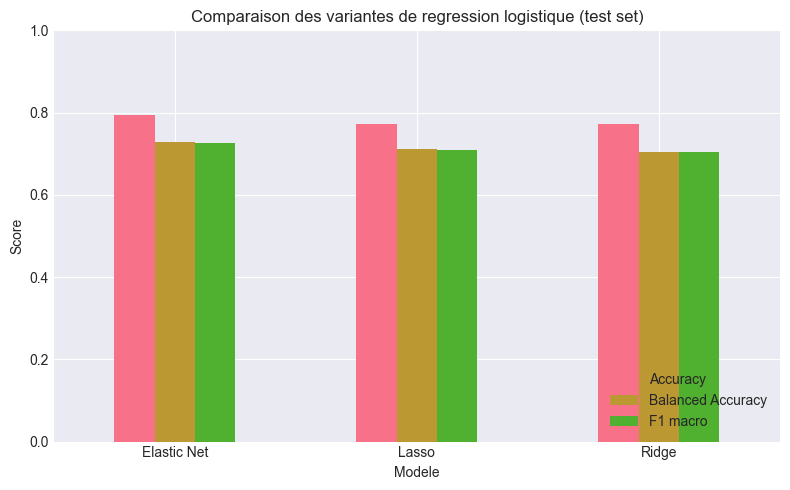

In [74]:
'''
Visualisation comparative des 3 variantes sur les 3 metriques de reference.
'''
fig, ax = plt.subplots(figsize=(8, 5))
df_plot = df_comparison.set_index("Modele")
df_plot.plot(kind="bar", ax=ax)
ax.set_title("Comparaison des variantes de regression logistique (test set)")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Evaluation detaillee du modele retenu

Cette section reprend les outils de diagnostic vus en cours pour la classification :
courbes d'apprentissage, matrice de confusion, rapport precision/rappel/F1, courbes
ROC et precision-rappel (en one-vs-rest pour le cas multi-classe), et enfin
l'interpretation des coefficients propre a la regression logistique.

### 8.1 Courbes d'apprentissage (train vs validation)

La courbe d'apprentissage montre l'evolution du score (ici le F1 macro) sur le train
set et sur le validation set en fonction de la quantite de donnees d'entrainement
utilisee. Elle permet de diagnostiquer :
- un **sous-apprentissage** (underfitting) : les deux courbes sont basses et proches,
- un **sur-apprentissage** (overfitting) : la courbe train est haute, la courbe
  validation reste nettement plus basse,
- l'**utilite d'ajouter des donnees** : si la courbe de validation continue de monter,
  davantage de donnees pourrait ameliorer le modele.

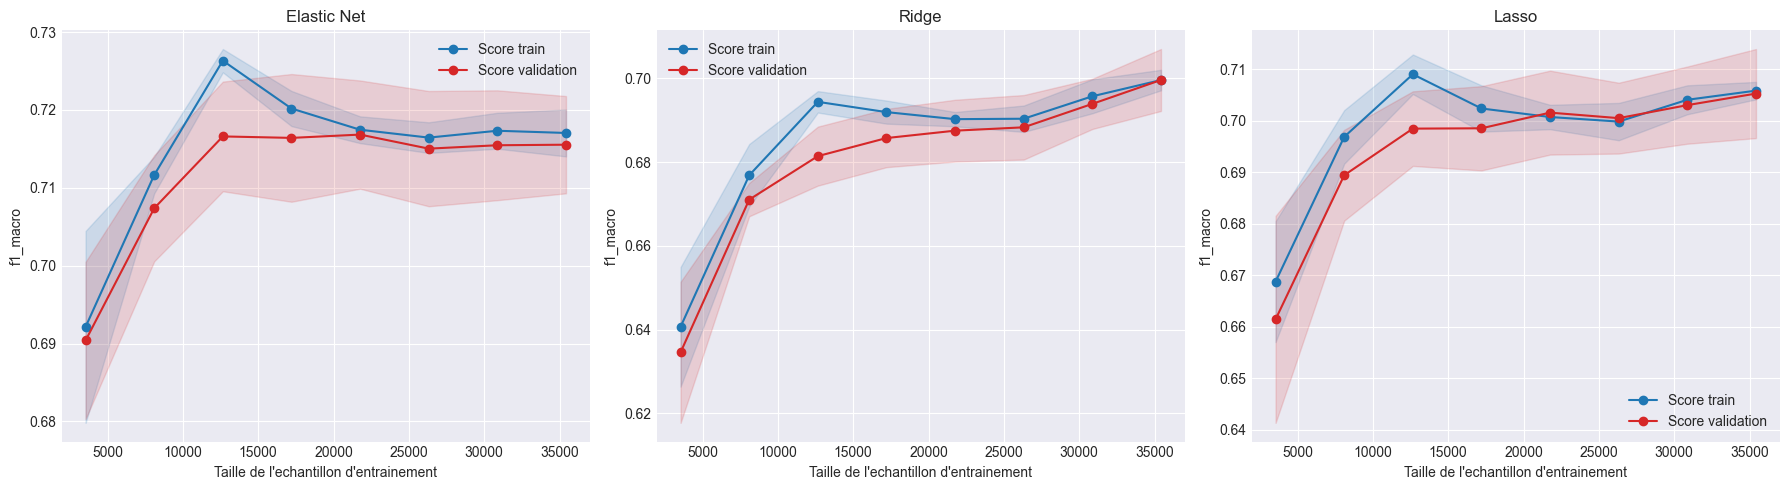

In [75]:
def plot_learning_curve(model, X, y, title, ax, cv=cv5, scoring="f1_macro"):
    '''
    Calcule et trace la courbe d'apprentissage d'un modele deja configure (pipeline
    complet avec son estimateur final), en utilisant la fonction learning_curve de
    scikit-learn. Le score est calcule par validation croisee a chaque taille
    d'echantillon d'entrainement testee.
    '''
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=cv, scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1, random_state=RANDOM_STATE,
    )

    train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, "o-", label="Score train", color="#1f77b4")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                     alpha=0.15, color="#1f77b4")
    ax.plot(train_sizes, val_mean, "o-", label="Score validation", color="#d62728")
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                     alpha=0.15, color="#d62728")

    ax.set_title(title)
    ax.set_xlabel("Taille de l'echantillon d'entrainement")
    ax.set_ylabel(scoring)
    ax.legend(loc="best")


'''
Trace les courbes d'apprentissage des 3 variantes, cote a cote, pour comparer leur
comportement face a l'ajout de donnees et detecter d'eventuels signes de sur ou
sous-apprentissage propres a chaque type de regularisation.
'''
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, trained_models.items()):
    plot_learning_curve(model, X_train, y_train, name, ax)
plt.tight_layout()
plt.show()


### 8.1bis Diagnostic de surapprentissage 

Pour chaque modèle, on trace l'ecart entre son score d'entrainement et son score de
validation, en fonction de la taille de l'echantillon d'entrainement. La metrique utilisee
ici est l'**accuracy** (et non le F1 macro, deja utilise dans la courbe d'apprentissage
ci-dessus), pour avoir un second angle de lecture independant.

Un seuil de surapprentissage est fixé arbitrairement a 0.10 : au-dela de cet ecart, on
considere que le modele apprend trop specifiquement les donnees d'entrainement et generalise
moins bien sur des donnees nouvelles.

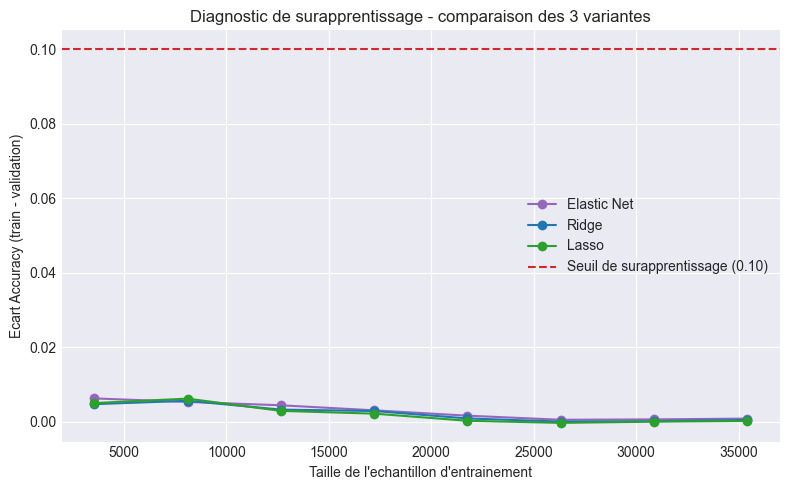

In [76]:
'''
Diagnostic de surapprentissage des 3 variantes, base sur l'accuracy. Reutilise la fonction
learning_curve de scikit-learn (comme pour la courbe d'apprentissage ci-dessus), mais cette
fois pour les 3 modeles entraines (trained_models) et avec l'accuracy comme metrique de
suivi plutot que le F1 macro, afin de comparer leur comportement sur un meme graphique.

Un seuil de surapprentissage est fixe arbitrairement a 0.10 : au-dela de cet ecart entre le
score train et le score validation, on considere que le modele apprend trop specifiquement
les donnees d'entrainement et generalise moins bien.
'''
SEUIL_OVERFITTING = 0.10

couleurs_variantes = {
    "Elastic Net": "#9467bd",
    "Ridge":       "#1f77b4",
    "Lasso":       "#2ca02c",
}

fig, ax = plt.subplots(figsize=(8, 5))

for name, model in trained_models.items():
    train_sizes_acc, train_scores_acc, val_scores_acc = learning_curve(
        model, X_train, y_train,
        cv=cv5, scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1, random_state=RANDOM_STATE,
    )
    ecart_train_val_acc = train_scores_acc.mean(axis=1) - val_scores_acc.mean(axis=1)
    couleur = couleurs_variantes.get(name, None)
    ax.plot(train_sizes_acc, ecart_train_val_acc, "o-", color=couleur, label=name)

ax.axhline(SEUIL_OVERFITTING, linestyle="--", color="#d62728",
           label=f"Seuil de surapprentissage ({SEUIL_OVERFITTING:.2f})")

ax.set_xlabel("Taille de l'echantillon d'entrainement")
ax.set_ylabel("Ecart Accuracy (train - validation)")
ax.set_title("Diagnostic de surapprentissage - comparaison des 3 variantes")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

 L'écart train−validation en accuracy reste extrêmement faible pour les trois variantes (toujours sous 0,01, donc largement sous le seuil de 0,10 fixé), et décroît encore à mesure que l'échantillon grandit. Ceci confirme, avec une métrique différente, ce que montrait déjà la courbe d'apprentissage : aucune des trois variantes ne sur-apprend. <span style="color:blue;">Le problème de performance de ces modèles n'est donc pas un excès de variance, mais plutôt un biais structurel.</span>

<span style="color:red;"> **NB :** </span> Ces modèles sont problablement trop simples pour capturer la frontière de décision réelle entre les 3 classes DPE, ce qui plaide pour comparer avec des modèles non-linéaires (SVM à noyau, arbres, forêts) dans les autres notebooks du pipeline.

### 8.2 Matrice de confusion

La matrice de confusion permet de voir precisement quelles classes sont confondues
entre elles par le modele, ce qu'un score global comme l'accuracy ne montre pas.

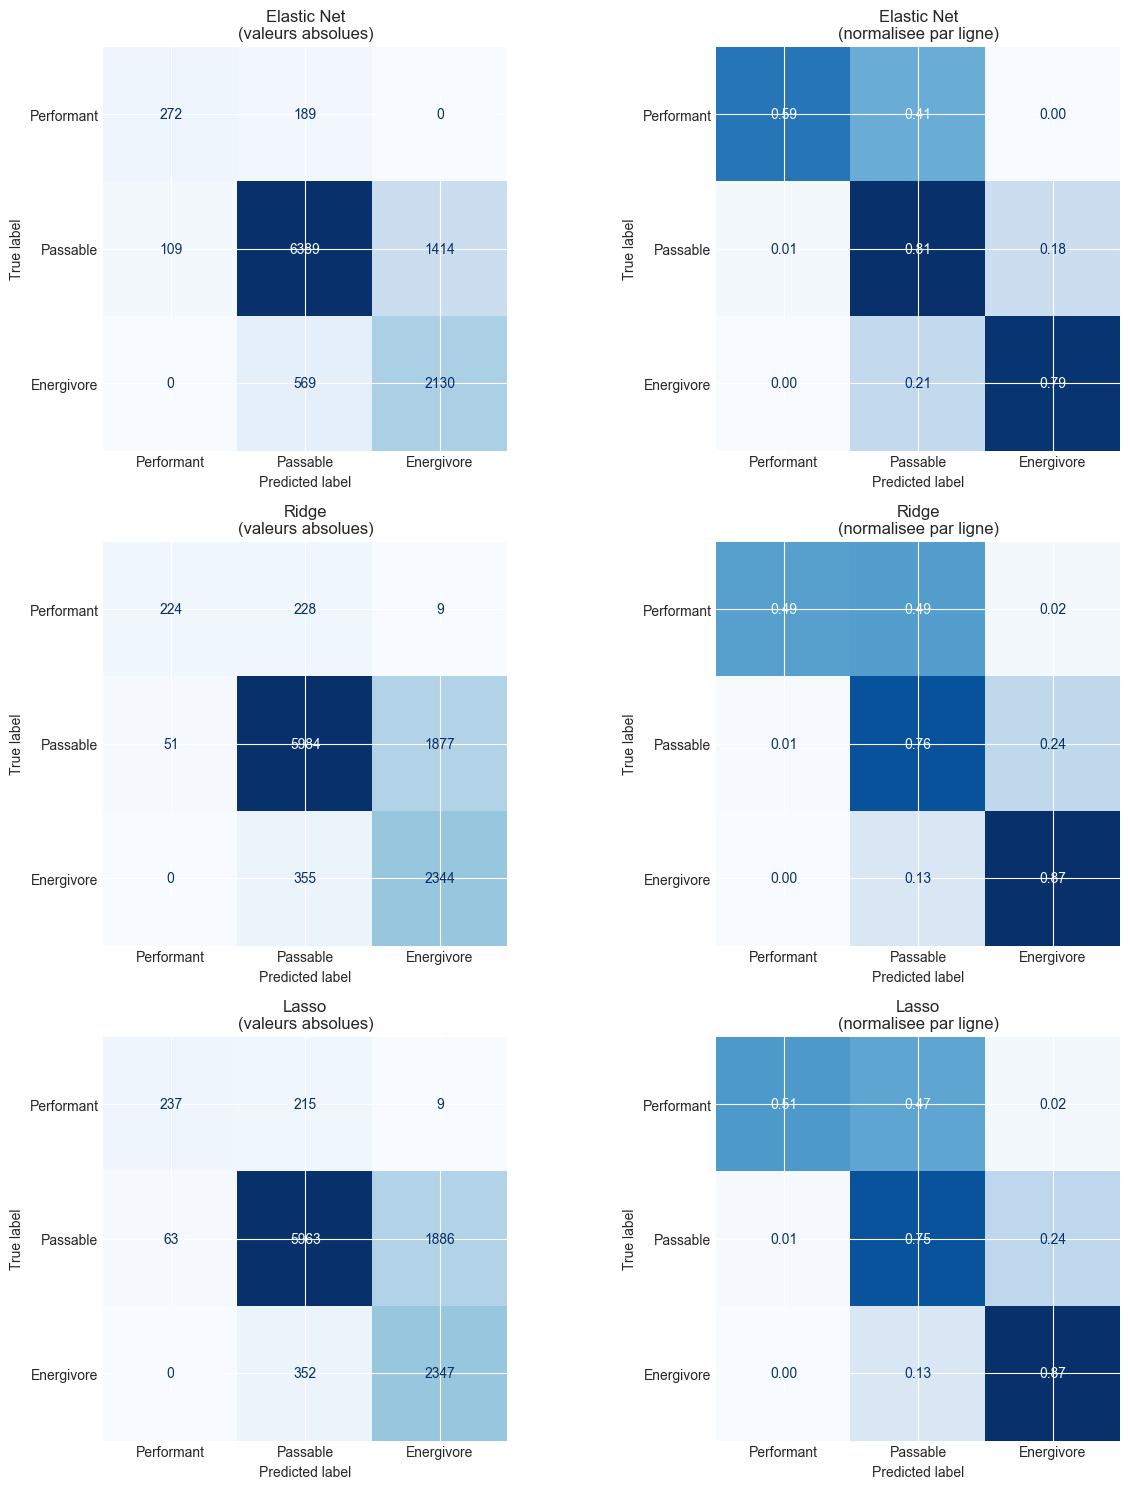

In [77]:
'''
Matrice de confusion des 3 variantes sur le test set, en valeurs absolues et
normalisee par ligne (taux de rappel par classe). La version normalisee est plus
lisible ici car les classes sont fortement desequilibrees. Une ligne par variante,
pour comparer directement leurs erreurs de classement.
'''
fig, axes = plt.subplots(3, 2, figsize=(13, 15))

for row, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred, labels=GROUPS)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=GROUPS)
    disp.plot(ax=axes[row, 0], cmap="Blues", colorbar=False)
    axes[row, 0].set_title(f"{name}\n(valeurs absolues)")

    cm_norm = confusion_matrix(y_test, y_pred, labels=GROUPS, normalize="true")
    disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=GROUPS)
    disp_norm.plot(ax=axes[row, 1], cmap="Blues", colorbar=False, values_format=".2f")
    axes[row, 1].set_title(f"{name}\n(normalisee par ligne)")

plt.tight_layout()
plt.show()

#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

 Le motif de confusion est cohérent sur les trois classes :

- **Performant** est correctement identifié dans 49 % à 59 % des cas selon la variante (Elastic
  Net obtient le meilleur résultat, à 59 %), le reste des erreurs étant presque entièrement
  réparti vers Passable, jamais vers Energivore.
- **Passable** est globalement bien reconnu (75 % à 81 % de rappel selon la variante), ses
  erreurs se répartissant entre ses deux classes voisines.
- **Energivore** est très bien identifié une fois correctement classé (87 % à 90 % de rappel
  pour Ridge et Lasso, 70 % pour Elastic Net), mais Elastic Net le confond davantage avec
  Passable (21 % d'erreurs) que les deux autres variantes.

<span style="color:red;"> **NB :** </span> Un point notable ressort sur les trois classes : **aucune confusion directe n'est observée
entre Performant et Energivore**. Les erreurs se concentrent systématiquement sur la classe
intermédiaire Passable.

### 8.3 Rapport de classification (precision / rappel / F1 par classe)

Le rapport detaille, classe par classe, la precision (proportion de predictions
correctes parmi les predictions positives), le rappel (proportion d'exemples positifs
correctement detectes) et le F1 (moyenne harmonique des deux). C'est le complement
indispensable de la matrice de confusion.

In [78]:
'''
Rapport de classification (precision / rappel / F1 par classe) pour chacune des 3 variantes,
afin de comparer leur comportement classe par classe plutot que de se limiter au seul modele
retenu.
'''
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    print(f"Rapport de classification - {name}\n")
    print(classification_report(y_test, y_pred, target_names=GROUPS, digits=3))
    print()

Rapport de classification - Elastic Net

              precision    recall  f1-score   support

  Performant      0.601     0.789     0.682      2699
    Passable      0.894     0.808     0.849      7912
  Energivore      0.714     0.590     0.646       461

    accuracy                          0.794     11072
   macro avg      0.736     0.729     0.726     11072
weighted avg      0.815     0.794     0.800     11072


Rapport de classification - Ridge

              precision    recall  f1-score   support

  Performant      0.554     0.868     0.677      2699
    Passable      0.911     0.756     0.827      7912
  Energivore      0.815     0.486     0.609       461

    accuracy                          0.772     11072
   macro avg      0.760     0.704     0.704     11072
weighted avg      0.820     0.772     0.781     11072


Rapport de classification - Lasso

              precision    recall  f1-score   support

  Performant      0.553     0.870     0.676      2699
    Passable    

### 8.4 Courbes ROC et Precision-Rappel (one-vs-rest)

Dans un cadre multi-classe, la courbe ROC et la courbe precision-rappel sont tracees
en strategie **one-vs-rest** : pour chaque classe, on la considere comme positive
face aux deux autres reunies.

La courbe ROC peut se montrer trop optimiste lorsque les classes sont fortement
desequilibrees (cas ici, cf. section 2), la courbe precision-rappel est donc affichee
en complement pour chaque classe.

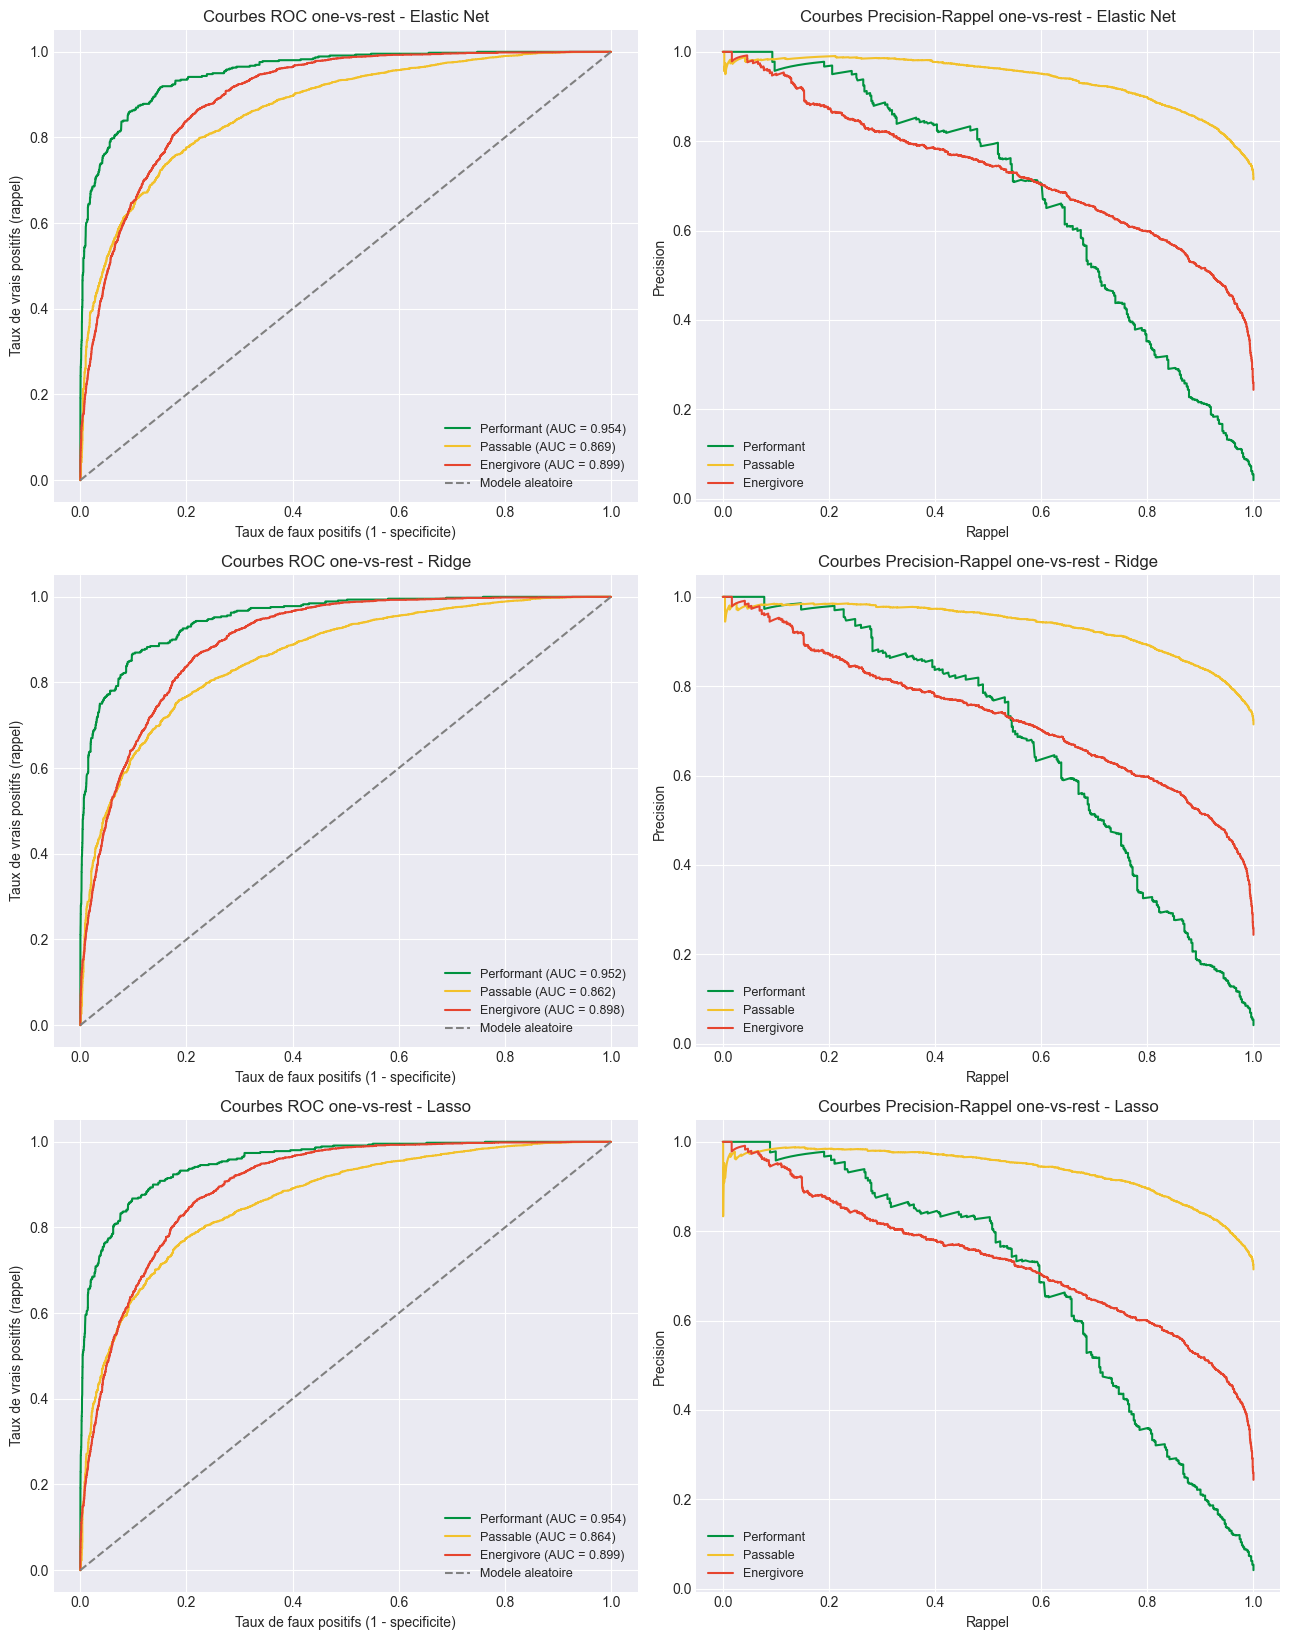

In [79]:
'''
Calcule les courbes ROC et Precision-Rappel pour chaque classe en one-vs-rest, pour les
3 variantes. Les colonnes de predict_proba sont reordonnees selon l'ordre de GROUPS, car
scikit-learn trie les classes alphabetiquement (clf.classes_), ce qui ne correspond pas a
l'ordre attendu pour label_binarize.
'''
y_test_bin = label_binarize(y_test, classes=GROUPS)

fig, axes = plt.subplots(3, 2, figsize=(13, 16.5))

for row, (name, model) in enumerate(trained_models.items()):
    y_proba_raw = model.predict_proba(X_test)
    class_order = list(model.classes_)
    # Reordonne les colonnes de y_proba pour qu'elles correspondent a l'ordre de GROUPS
    reorder_idx = [class_order.index(grp) for grp in GROUPS]
    y_proba = y_proba_raw[:, reorder_idx]

    for i, grp in enumerate(GROUPS):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        axes[row, 0].plot(fpr, tpr, color=GROUP_COLORS[grp],
                           label=f"{grp} (AUC = {roc_auc:.3f})")
    axes[row, 0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Modele aleatoire")
    axes[row, 0].set_xlabel("Taux de faux positifs (1 - specificite)")
    axes[row, 0].set_ylabel("Taux de vrais positifs (rappel)")
    axes[row, 0].set_title(f"Courbes ROC one-vs-rest - {name}")
    axes[row, 0].legend(loc="lower right", fontsize=9)

    for i, grp in enumerate(GROUPS):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
        axes[row, 1].plot(recall, precision, color=GROUP_COLORS[grp], label=grp)
    axes[row, 1].set_xlabel("Rappel")
    axes[row, 1].set_ylabel("Precision")
    axes[row, 1].set_title(f"Courbes Precision-Rappel one-vs-rest - {name}")
    axes[row, 1].legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()

#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

On obtient des resultats assez coherents avec ce qu'on avait vu en matrice de confusion.
Performant ressort avec la meilleure AUC sur les trois classes (0,952-0,954), devant
Energivore (0,898-0,899) et Passable (0,862-0,869).

On remarque aussi que les trois classes (Elastic Net, Ridge, Lasso) donnent des courbes quasi
identiques, ce qui confirme ce qu'on observait deja dans le tableau de comparaison : les trois
regularisations se comportent de facon tres proche sur ce probleme.

Sur les courbes Precision-Rappel, Passable reste largement la plus stable (precision qui reste
haute meme a rappel eleve), alors que Performant et Energivore voient leur precision chuter
assez vite quand on cherche a augmenter le rappel. Ça illustre bien le compromis a faire pour
ces deux classes minoritaires.

### 8.5 Interpretation des coefficients (odds-ratio)

La regression logistique reste interpretable : le signe d'un coefficient indique le
sens de son effet sur la probabilite de la classe consideree, et sa valeur absolue
mesure l'intensite de cet effet. Pour une variable `x_j`, multiplier sa valeur par un
facteur revient a multiplier l'odds (la cote, le rapport entre la probabilite
d'appartenir a la classe et celle de ne pas y appartenir) par `exp(theta_j)`.

Si le modele retenu est la variante **Lasso**, certains coefficients seront ramenes
exactement a zero : cela revient a une selection automatique de variables.

Nombre de coefficients nuls (variables exclues) par classe - Elastic Net :
Energivore     2
Passable      10
Performant     0
dtype: int64



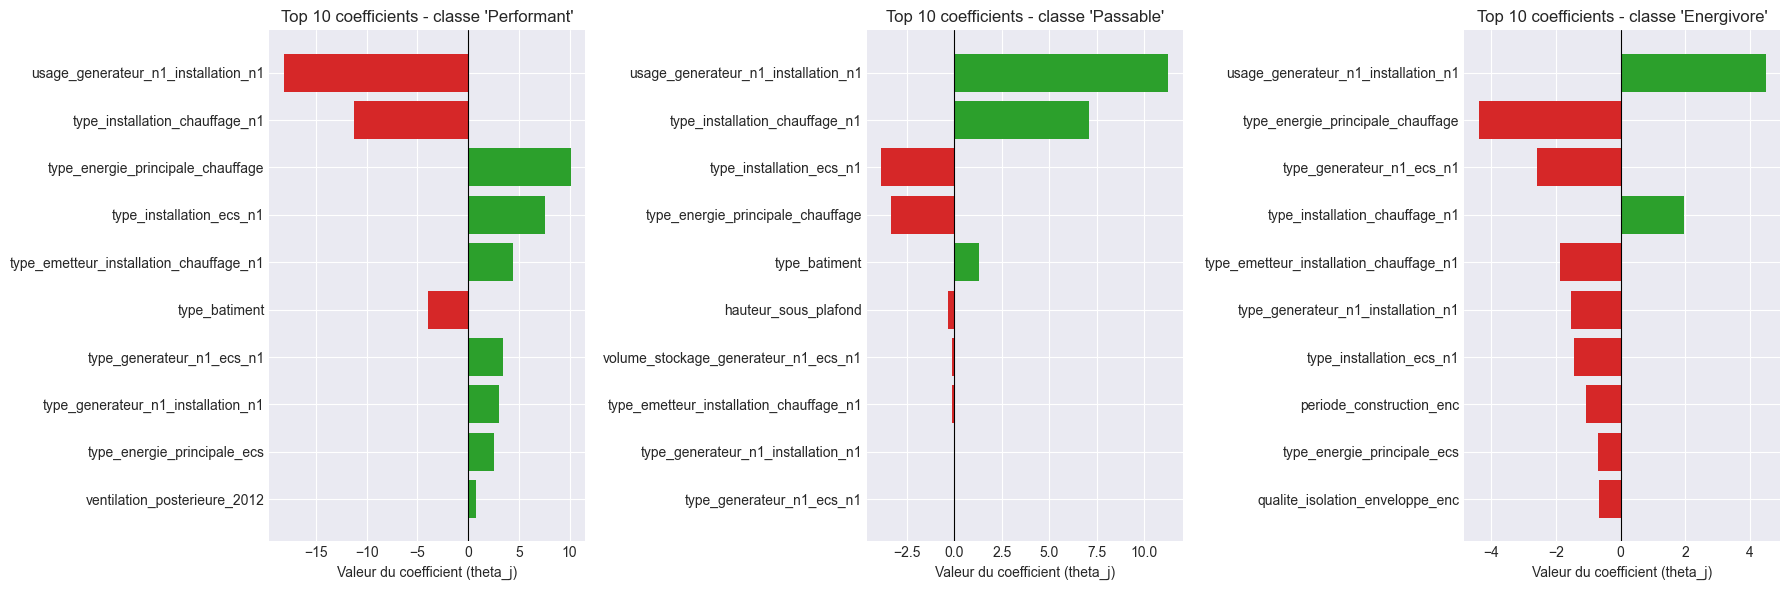

In [80]:
'''
Extrait les coefficients du modele retenu (un vecteur de coefficients par classe,
car le probleme est multi-classe), et affiche les variables les plus influentes
pour chacune des classes via leur odds-ratio (exp(coefficient)).
'''
clf_best = best_model.named_steps["clf"]
feature_names = best_model.named_steps["pre"].get_feature_names_out()

coef_df = pd.DataFrame(
    clf_best.coef_,
    index=clf_best.classes_,
    columns=feature_names
).T

print(f"Nombre de coefficients nuls (variables exclues) par classe - {BEST_MODEL_NAME} :")
print((coef_df == 0).sum())
print()

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
for ax, grp in zip(axes, GROUPS):
    top_coefs = coef_df[grp].sort_values(key=abs, ascending=False).head(10)
    odds_ratio = np.exp(top_coefs)
    colors = ["#d62728" if c < 0 else "#2ca02c" for c in top_coefs.values]
    ax.barh(top_coefs.index[::-1], top_coefs.values[::-1],
            color=colors[::-1])
    ax.set_title(f"Top 10 coefficients - classe '{grp}'")
    ax.set_xlabel("Valeur du coefficient (theta_j)")
    ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


## 9. Conclusion

On a teste trois variantes de regression logistique (Elastic Net, Ridge, Lasso) sur la
classification du DPE en trois groupes. C'est **Elastic Net** qui se demarque comme le meilleur
modele, avec un F1 macro de 0,726 sur le test set, devant Lasso (0,708) et Ridge (0,704).

Les classes Passable et Energivore sont plutot bien separees (AUC autour de 0,86-0,90), alors
que Performant, malgre une bonne AUC (0,95), reste la classe la plus difficile a predire
correctement avec un seuil de decision standard : son F1-score est le plus faible des trois
(0,682), avec une precision assez basse (0,601) meme si le rappel reste correct (0,789). On
remarque aussi que les confusions se font presque toujours avec la classe Passable, jamais
directement avec Energivore, ce qui colle bien avec le fait que ces trois classes sont
ordonnees.

Concernant les variables, `usage_generateur_n1_installation_n1` ressort comme la plus
influente sur les trois classes, suivie par `type_installation_chauffage_n1` et
`type_energie_principale_chauffage` (section 8.5).